<a href="https://colab.research.google.com/github/yyj1212-art/Python-for-Bioinformatics/blob/main/notebooks/CHO_Cell_RNAseq_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# 1. 데이터를 엑셀처럼 다루게 해주는 'pandas' 라이브러리 불러오기
import pandas as pd

# 2. 코랩에 업로드한 CHO 세포 데이터(압축파일)를 읽어서 'cho_counts'라는 변수에 저장하기
cho_counts = pd.read_csv("GSE294982_gene_counts.csv.gz")

# 3. 데이터가 잘 들어왔는지 표의 맨 위 5줄만 화면에 출력해보기
cho_counts.head()

,gene_id,B12_17_R1,B12_17_R2,B12_17_R3,B12_21_R1,B12_21_R2,B12_21_R3,B12_R1,B12_R2,B12_R3,clone1-wt_R1,clone1-wt_R2,clone1-wt_R3,clone1_1_R1,clone1_1_R2,clone1_1_R3,clone1_3_R1,clone1_3_R2,clone1_3_R3,Unnamed: 19
0,A1cf,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.000,0.0000,NaN
1,A3galt2,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,1.000,0.000,0.0000,0.0000,0.000,0.0000,NaN
2,A4galt,1.0000,1.0000,2.0000,1.0000,5.0000,0.0000,4.0000,2.0000,2.00000,0.0000,1.0000,0.0000,0.000,0.000,1.0000,3.0000,1.000,0.0000,NaN
3,A4gnt,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.00000,0.0000,1.0000,0.0000,0.000,0.000,0.0000,0.0000,0.000,0.0000,NaN
4,Aaas,1542.9955,1444.9967,1332.9992,1521.9988,1589.0019,1493.9965,777.9996,850.9999,667.00039,749.9996,835.9996,799.0005,1656.004,1364.995,1136.0034,1379.0025,1279.001,1875.9989,NaN


In [6]:
# 데이터의 전체 크기(행, 열 개수)와 데이터 타입을 한눈에 요약해서 보기
cho_counts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20076 entries, 0 to 20075
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gene_id       20076 non-null  object 
 1   B12_17_R1     20076 non-null  float64
 2   B12_17_R2     20076 non-null  float64
 3   B12_17_R3     20076 non-null  float64
 4   B12_21_R1     20076 non-null  float64
 5   B12_21_R2     20076 non-null  float64
 6   B12_21_R3     20076 non-null  float64
 7   B12_R1        20076 non-null  float64
 8   B12_R2        20076 non-null  float64
 9   B12_R3        20076 non-null  float64
 10  clone1-wt_R1  20076 non-null  float64
 11  clone1-wt_R2  20076 non-null  float64
 12  clone1-wt_R3  20076 non-null  float64
 13  clone1_1_R1   20076 non-null  float64
 14  clone1_1_R2   20076 non-null  float64
 15  clone1_1_R3   20076 non-null  float64
 16  clone1_3_R1   20076 non-null  float64
 17  clone1_3_R2   20076 non-null  float64
 18  clone1_3_R3   20076 non-nu

In [7]:
# 1. 19번 쓰레기 열('Unnamed: 19')을 데이터에서 완전히 삭제하기
# axis=1은 '열(세로줄)'을 지우겠다는 뜻
cho_clean = cho_counts.drop(columns=['Unnamed: 19'], axis=1)

# 2. 삭제 후 데이터가 잘 정제되었는지 다시 확인
cho_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20076 entries, 0 to 20075
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gene_id       20076 non-null  object 
 1   B12_17_R1     20076 non-null  float64
 2   B12_17_R2     20076 non-null  float64
 3   B12_17_R3     20076 non-null  float64
 4   B12_21_R1     20076 non-null  float64
 5   B12_21_R2     20076 non-null  float64
 6   B12_21_R3     20076 non-null  float64
 7   B12_R1        20076 non-null  float64
 8   B12_R2        20076 non-null  float64
 9   B12_R3        20076 non-null  float64
 10  clone1-wt_R1  20076 non-null  float64
 11  clone1-wt_R2  20076 non-null  float64
 12  clone1-wt_R3  20076 non-null  float64
 13  clone1_1_R1   20076 non-null  float64
 14  clone1_1_R2   20076 non-null  float64
 15  clone1_1_R3   20076 non-null  float64
 16  clone1_3_R1   20076 non-null  float64
 17  clone1_3_R2   20076 non-null  float64
 18  clone1_3_R3   20076 non-nu

In [8]:
# 1. gene_id 열을 제외하고, 모든 샘플(숫자 열)의 행별 합계 계산하기
# iloc[:, 1:]는 0번째 열(gene_id)을 제외한 모든 숫자 세로줄을 뜻함.
row_sums = cho_clean.iloc[:, 1:].sum(axis=1)

# 2. 모든 샘플의 발현량 합이 10 이상인 유전자만 골라내기 (노이즈 필터링)
cho_filtered = cho_clean[row_sums >= 10]

# 3. 필터링 후 몇 개의 유전자가 남았는지 행의 개수 확인하기
print("필터링 전 유전자 개수:", len(cho_clean))
print("필터링 후 유전자 개수:", len(cho_filtered))

필터링 전 유전자 개수: 20076
필터링 후 유전자 개수: 13362


In [11]:
import pandas as pd
import numpy as np
from scipy import stats

# [1단계] 데이터 불러오기
print("1. CHO 세포 데이터를 불러오는 중입니다...")
cho_counts = pd.read_csv("GSE294982_gene_counts.csv.gz")

# [2단계] 데이터 청소 (유령 열 삭제)
print("2. 데이터 노령 열(쓰레기 데이터)을 청소하는 중입니다...")
cho_clean = cho_counts.drop(columns=['Unnamed: 19'], axis=1)

# [3단계] 노이즈 필터링 (발현량 합 10 이상)
print("3. 발현량이 너무 낮은 노이즈 유전자를 걸러내는 중입니다...")
row_sums = cho_clean.iloc[:, 1:].sum(axis=1)
cho_filtered = cho_clean[row_sums >= 10]

# [4단계] 대조군(WT) 대비 실험군(개량형)의 유전자 발현 변화 통계 검정
print("4. 대조군(WT) 대비 실험군(개량형)의 유전자 발현 변화를 통계 검정 중입니다...")
cho_final = cho_filtered.copy()

control_cols = ['clone1-wt_R1', 'clone1-wt_R2', 'clone1-wt_R3']
exp_cols = ['clone1_1_R1', 'clone1_1_R2', 'clone1_1_R3']

# 평균 및 발현 배수(Log2 Fold Change) 계산
control_mean = cho_final[control_cols].mean(axis=1) + 1e-5
exp_mean = cho_final[exp_cols].mean(axis=1) + 1e-5
cho_final['log2FC'] = np.log2(exp_mean / control_mean)

# 🔥 [버그 수정 포인트] for 루프를 없애고 데이터 타입을 강제로 숫자(float)로 지정하여 한 번에 계산
# axis=1을 주면 수만 개의 행을 단 0.1초 만에 에러 없이 통계 검정합니다.
_, p_values = stats.ttest_ind(
    cho_final[control_cols].astype(float),
    cho_final[exp_cols].astype(float),
    axis=1,
    equal_var=False
)

cho_final['p_value'] = p_values
cho_final['minus_log10_p'] = -np.log10(cho_final['p_value'] + 1e-10)

print("🎉 축하합니다! 모든 전처리 및 통계 계산이 완벽하게 끝났습니다.")
print("-" * 60)

# 결과 상위 5줄 출력
cho_final[['gene_id', 'log2FC', 'p_value', 'minus_log10_p']].head()

1. CHO 세포 데이터를 불러오는 중입니다...
2. 데이터 노령 열(쓰레기 데이터)을 청소하는 중입니다...
3. 발현량이 너무 낮은 노이즈 유전자를 걸러내는 중입니다...
4. 대조군(WT) 대비 실험군(개량형)의 유전자 발현 변화를 통계 검정 중입니다...
🎉 축하합니다! 모든 전처리 및 통계 계산이 완벽하게 끝났습니다.
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


,gene_id,log2FC,p_value,minus_log10_p
2,A4galt,0.000000,1.000000,-4.342945e-11
4,Aaas,0.801554,0.055666,1.254413e+00
5,Aacs,0.228061,0.281154,5.510564e-01
8,Aagab,0.694391,0.051516,1.288060e+00
9,Aamdc,0.515838,0.156980,8.041561e-01


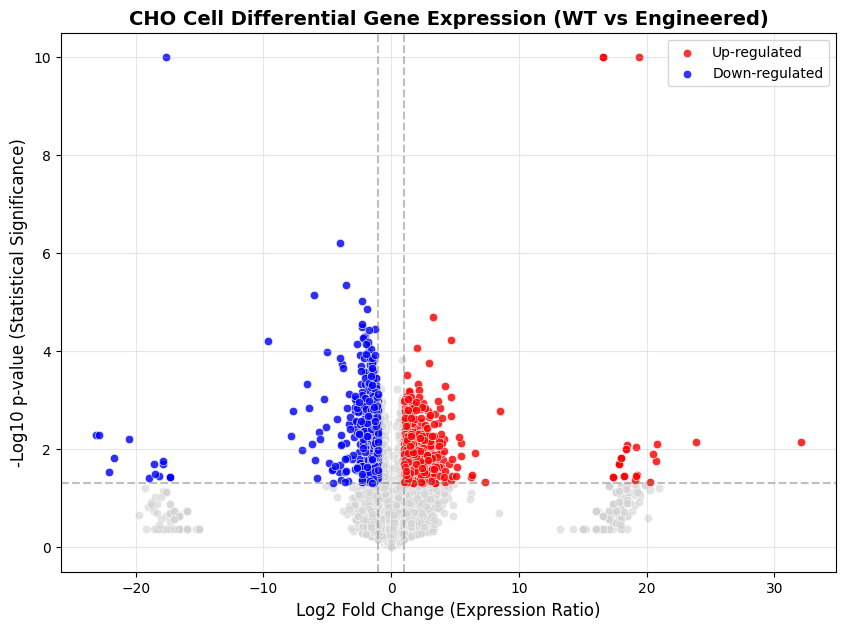

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 그래프 크기 설정
plt.figure(figsize=(10, 7))

# 1. 배경에 모든 유전자를 연한 회색 점으로 그리기 (영향 없는 유전자들)
sns.scatterplot(data=cho_final, x='log2FC', y='minus_log10_p', color='lightgrey', alpha=0.6)

# 2. 통계적으로 유의미하게 발현이 증가한 핵심 유전자(오른쪽 위)를 붉은색으로 강조
# 기준: 발현량이 2배 이상 증가(log2FC > 1)하고, 우연일 확률이 5% 미만(p_value < 0.05)
up_regulated = cho_final[(cho_final['log2FC'] > 1) & (cho_final['p_value'] < 0.05)]
sns.scatterplot(data=up_regulated, x='log2FC', y='minus_log10_p', color='red', alpha=0.8, label='Up-regulated')

# 3. 통계적으로 유의미하게 발현이 감소한 핵심 유전자(왼쪽 위)를 푸른색으로 강조
# 기준: 발현량이 2배 이상 감소(log2FC < -1)하고, 우연일 확률이 5% 미만(p_value < 0.05)
down_regulated = cho_final[(cho_final['log2FC'] < -1) & (cho_final['p_value'] < 0.05)]
sns.scatterplot(data=down_regulated, x='log2FC', y='minus_log10_p', color='blue', alpha=0.8, label='Down-regulated')

# 4. 과학적 기준선(Threshold) 그리기 (점선 가이드라인)
plt.axhline(y=-np.log10(0.05), color='gray', linestyle='--', alpha=0.5) # p=0.05 기준선
plt.axvline(x=1, color='gray', linestyle='--', alpha=0.5)              # 2배 증가선
plt.axvline(x=-1, color='gray', linestyle='--', alpha=0.5)             # 2배 감소선

# 5. 그래프 제목 및 축 이름 예쁘게 꾸미기
plt.title('CHO Cell Differential Gene Expression (WT vs Engineered)', fontsize=14, fontweight='bold')
plt.xlabel('Log2 Fold Change (Expression Ratio)', fontsize=12)
plt.ylabel('-Log10 p-value (Statistical Significance)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 그래프 화면에 출력
plt.show()